## 1. Compare Portfolios

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
t_eval = np.load('data/t_eval.npy', allow_pickle = True)
spy_returns = pd.read_csv('data/spy_returns.csv', index_col = 0, parse_dates = True)
benchmark = (1 + spy_returns.reindex(t_eval)).cumprod()

In [29]:
factor_returns = pd.read_csv('outputs/factor_returns.csv', index_col = 0, parse_dates = True)
ra_returns = pd.read_csv('outputs/ra_returns.csv', index_col = 0, parse_dates = True)

factor_portfolio = (1 + factor_returns).cumprod().squeeze()
ra_portfolio = (1 + ra_returns).cumprod().squeeze()

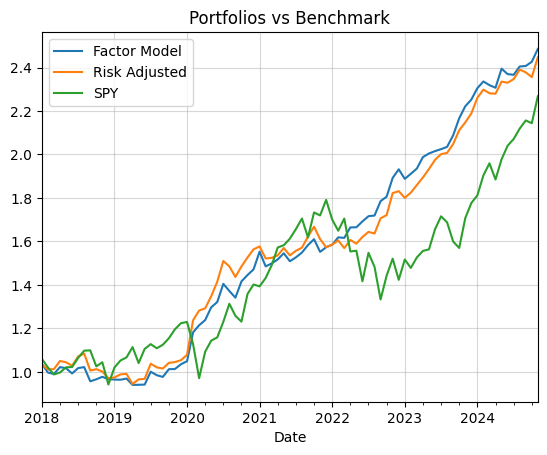

In [32]:
fig, ax = plt.subplots()

factor_portfolio.plot(ax=ax, label='Factor Model')
ra_portfolio.plot(ax=ax, label='Risk Adjusted')
benchmark.plot(ax=ax, label='Benchmark')

ax.set_title('Portfolios vs Benchmark')
ax.grid(alpha=0.5)
ax.legend()

plt.savefig("outputs/Portfolios_vs_Benchmark.png")

## 2. Portfolio Analytics

In [ ]:
def analyse_portfolio(portfolio_returns):
    mean = portfolio_returns.mean()
    std = portfolio_returns.std()
    sharpe = np.sqrt(12) * mean / std

    portfolio = (1 + portfolio_returns).cumprod()
    total_return = portfolio.iloc[-1] - 1
    annual_return = (1 + total_return) ** (12 / len(portfolio)) - 1
    running_max = portfolio.cummax()
    drawdown = portfolio / running_max - 1
    max_dd = drawdown.min()

    print(f"Mean Return: {mean * 100:.2f}%")
    print(f"Mean Std: {std * 100:.2f}%")
    print(f"Sharpe Ratio: {sharpe:.2f}")
    print(f"Total Returns: {total_return * 100:.0f}%")
    print(f"Annual Return: {annual_return * 100:.0f}%")
    print(f"Max drawdown: {max_dd * 100:.0f}%")

    return mean, std, sharpe, total_return, annual_return, max_dd
